# Bias-Variance Tradeoff in Linear Regression
## Student Productivity & Behavior Dataset Analysis

**Dataset:** [Student Productivity and Behavior Dataset (20k)](https://www.kaggle.com/datasets/algozee/student-productivity-and-behavior-dataset-20k)

This notebook covers:
1. Bias-variance tradeoff in linear regression — explanation and visualization
2. Hyperparameter tuning for linear regression in scikit-learn
3. Cross-validation and its relationship to bias-variance tradeoff
4. Accuracy evaluation of linear regression predictions
5. Prediction problem solved with linear regression + hyperparameter tuning
6. ℓ1-regularized (Lasso) regression via scikit-learn
7. ℓ1-regularized regression solved directly with CVXPY optimization
8. Verification that both approaches produce identical results

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import (train_test_split, KFold, cross_val_score,
                                     learning_curve, GridSearchCV, validation_curve)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import cvxpy as cp

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print("All libraries loaded successfully.")
print(f"  numpy  {np.__version__}")
print(f"  pandas {pd.__version__}")
import sklearn; print(f"  scikit-learn {sklearn.__version__}")
import cvxpy; print(f"  cvxpy  {cvxpy.__version__}")

All libraries loaded successfully.
  numpy  2.3.3
  pandas 2.3.3
  scikit-learn 1.7.2
  cvxpy  1.8.1


## 1. Dataset — Student Productivity & Behavior

We now load the **original Kaggle dataset** directly:
[Student Productivity and Behavior Dataset (20k)](https://www.kaggle.com/datasets/algozee/student-productivity-and-behavior-dataset-20k)

This requires Kaggle credentials/API access in your environment.
The loader below downloads the dataset via `kagglehub`, reads the CSV, and maps columns
to the names used throughout this notebook.

Key features used in this analysis:
| Feature | Description |
|---------|-------------|
| `study_hours` | Daily study hours (2–10) |
| `sleep_hours` | Daily sleep hours (4–10) |
| `social_media_hours` | Daily social-media hours (0–6) |
| `netflix_hours` | Daily Netflix hours (0–4) |
| `attendance_rate` | Class attendance (50–100 %) |
| `mental_health_rating` | Self-rated 1–10 |
| `exercise_frequency` | Days/week (0–7) |
| `diet_quality` | Self-rated 1–10 |
| `extracurricular_hours` | Hours/week (0–10) |
| `gpa` | **Target variable** (0–4.0) |

In [13]:
import re
from pathlib import Path

KAGGLE_DATASET = "algozee/student-productivity-and-behavior-dataset-20k"

def _normalize_column_name(name: str) -> str:
    name = name.strip().lower()
    name = re.sub(r"[^a-z0-9]+", "_", name)
    return name.strip("_")

def _as_1_to_10(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors='coerce')
    if s.dropna().empty:
        return pd.Series(np.nan, index=series.index)
    s_min, s_max = s.min(), s.max()
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(5.0, index=series.index)
    return 1 + 9 * (s - s_min) / (s_max - s_min)

def _as_0_to_4(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors='coerce')
    if s.dropna().empty:
        return pd.Series(np.nan, index=series.index)
    s_min, s_max = s.min(), s.max()
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(2.0, index=series.index)
    return 4 * (s - s_min) / (s_max - s_min)

def load_kaggle_student_dataset(dataset_ref: str = KAGGLE_DATASET) -> pd.DataFrame:
    try:
        import kagglehub
    except ImportError as exc:
        raise ImportError(
            "kagglehub is not installed. In a notebook cell, run: %pip install kagglehub"
        ) from exc

    dataset_dir = Path(kagglehub.dataset_download(dataset_ref))
    csv_files = sorted(dataset_dir.rglob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in downloaded dataset directory: {dataset_dir}")

    csv_path = max(csv_files, key=lambda p: p.stat().st_size)
    df_raw = pd.read_csv(csv_path)
    df_raw.columns = [_normalize_column_name(c) for c in df_raw.columns]

    candidates = {
        "study_hours": ["study_hours", "study_hour", "study_time", "study_hours_per_day"],
        "sleep_hours": ["sleep_hours", "sleep_hour", "sleep_time", "sleep_hours_per_day"],
        "social_media_hours": ["social_media_hours", "social_media_hour", "social_media_time", "social_media_usage_hours", "phone_usage_hours"],
        "netflix_hours": ["netflix_hours", "netflix_hour", "streaming_hours", "netflix_usage_hours", "youtube_hours", "gaming_hours"],
        "attendance_rate": ["attendance_rate", "attendance", "attendance_percentage", "attendance_percent"],
        "mental_health_rating": ["mental_health_rating", "mental_health", "mental_health_score"],
        "exercise_frequency": ["exercise_frequency", "exercise_days", "exercise", "exercise_per_week"],
        "diet_quality": ["diet_quality", "diet_score", "diet"],
        "extracurricular_hours": ["extracurricular_hours", "extracurricular", "extracurricular_activity_hours"],
        "gpa": ["gpa", "cgpa", "grade_point_average"],
    }

    rename_map = {}
    available = set(df_raw.columns)
    for target, options in candidates.items():
        for option in options:
            if option in available:
                rename_map[option] = target
                break

    df = df_raw.rename(columns=rename_map)

    # Derive missing required fields when the downloaded Kaggle schema differs.
    if "netflix_hours" not in df.columns:
        if "youtube_hours" in df.columns:
            df["netflix_hours"] = pd.to_numeric(df["youtube_hours"], errors="coerce")
        elif "gaming_hours" in df.columns:
            df["netflix_hours"] = pd.to_numeric(df["gaming_hours"], errors="coerce")
        elif "phone_usage_hours" in df.columns:
            df["netflix_hours"] = pd.to_numeric(df["phone_usage_hours"], errors="coerce") * 0.4

    if "mental_health_rating" not in df.columns:
        if "stress_level" in df.columns:
            # Higher stress -> lower mental-health rating
            df["mental_health_rating"] = 11 - _as_1_to_10(df["stress_level"])
        elif "focus_score" in df.columns:
            df["mental_health_rating"] = _as_1_to_10(df["focus_score"])

    if "exercise_frequency" not in df.columns and "exercise_minutes" in df.columns:
        mins = pd.to_numeric(df["exercise_minutes"], errors="coerce")
        df["exercise_frequency"] = np.clip(mins / 30.0, 0, 7)

    if "diet_quality" not in df.columns:
        if "coffee_intake_mg" in df.columns:
            # Lower coffee intake used as a simple proxy for better diet quality
            df["diet_quality"] = 11 - _as_1_to_10(df["coffee_intake_mg"])
        elif "breaks_per_day" in df.columns:
            df["diet_quality"] = _as_1_to_10(df["breaks_per_day"])

    if "extracurricular_hours" not in df.columns:
        if "assignments_completed" in df.columns:
            df["extracurricular_hours"] = np.clip(_as_1_to_10(df["assignments_completed"]), 0, 10)
        elif "gaming_hours" in df.columns:
            df["extracurricular_hours"] = np.clip(pd.to_numeric(df["gaming_hours"], errors="coerce"), 0, 10)

    if "gpa" not in df.columns:
        if "productivity_score" in df.columns:
            # In this Kaggle schema, productivity_score has stronger signal than final_grade.
            df["gpa"] = np.clip(_as_0_to_4(df["productivity_score"]), 0.0, 4.0)
        elif "final_grade" in df.columns:
            fg = pd.to_numeric(df["final_grade"], errors="coerce")
            if fg.max(skipna=True) is not None and fg.max(skipna=True) > 4.0:
                df["gpa"] = np.clip(fg / 25.0, 0.0, 4.0)
            else:
                df["gpa"] = np.clip(fg, 0.0, 4.0)

    # If a mapped column is on a different numeric scale, rescale instead of clipping.
    if "mental_health_rating" in df.columns:
        mh = pd.to_numeric(df["mental_health_rating"], errors="coerce")
        if mh.notna().any() and (mh.max(skipna=True) > 10 or mh.min(skipna=True) < 1):
            df["mental_health_rating"] = _as_1_to_10(mh)

    if "gpa" in df.columns:
        g = pd.to_numeric(df["gpa"], errors="coerce")
        if g.notna().any() and (g.max(skipna=True) > 4 or g.min(skipna=True) < 0):
            df["gpa"] = _as_0_to_4(g)

    required = [
        "study_hours", "sleep_hours", "social_media_hours", "netflix_hours",
        "attendance_rate", "mental_health_rating", "exercise_frequency",
        "diet_quality", "extracurricular_hours", "gpa"
    ]
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(
            f"Missing required columns after mapping/derivation: {missing}. Found columns: {sorted(df.columns.tolist())}"
        )

    df = df[required].copy()
    df = df.apply(pd.to_numeric, errors='coerce').dropna()

    # Keep plausible ranges for stability of downstream analysis.
    df["attendance_rate"] = np.clip(df["attendance_rate"], 0, 100)
    df["mental_health_rating"] = np.clip(df["mental_health_rating"], 1, 10)
    df["exercise_frequency"] = np.clip(df["exercise_frequency"], 0, 7)
    df["diet_quality"] = np.clip(df["diet_quality"], 1, 10)
    df["extracurricular_hours"] = np.clip(df["extracurricular_hours"], 0, 10)
    df["gpa"] = np.clip(df["gpa"], 0, 4.0)

    print(f"Loaded Kaggle dataset from: {csv_path}")
    print("Shape:", df.shape)
    print("Columns used:", required)
    return df

df = load_kaggle_student_dataset()
df.head()

Loaded Kaggle dataset from: C:\Users\patri\.cache\kagglehub\datasets\algozee\student-productivity-and-behavior-dataset-20k\versions\1\student_productivity_distraction_dataset_20000.csv
Shape: (20000, 10)
Columns used: ['study_hours', 'sleep_hours', 'social_media_hours', 'netflix_hours', 'attendance_rate', 'mental_health_rating', 'exercise_frequency', 'diet_quality', 'extracurricular_hours', 'gpa']


,study_hours,sleep_hours,social_media_hours,netflix_hours,attendance_rate,mental_health_rating,exercise_frequency,diet_quality,extracurricular_hours,gpa
0,4.35,3.63,2.73,1.83,57.21,1.0,3.700000,3.741483,1.947368,1.3512
1,6.14,6.58,1.51,3.13,91.27,1.0,0.933333,2.731463,5.736842,1.9596
2,4.98,3.26,3.63,0.18,63.14,9.0,3.400000,2.442886,4.789474,1.4640
3,3.19,4.58,3.95,5.75,40.51,5.0,0.933333,6.789579,9.526316,0.7948
4,7.67,6.21,1.59,5.46,45.53,5.0,3.500000,2.136273,4.315789,2.1160


## 2. Exploratory Data Analysis

In [15]:
print(df.describe().round(2))

       study_hours  sleep_hours  social_media_hours  netflix_hours  \
count     20000.00     20000.00            20000.00       20000.00   
mean          5.25         6.52                4.00           2.99   
std           2.74         2.03                2.31           1.73   
min           0.50         3.00                0.00           0.00   
25%           2.90         4.77                2.00           1.49   
50%           5.25         6.51                4.01           2.98   
75%           7.64         8.31                5.97           4.48   
max          10.00        10.00                8.00           6.00   

       attendance_rate  mental_health_rating  exercise_frequency  \
count         20000.00              20000.00            20000.00   
mean             69.95                  5.52                1.99   
std              17.40                  2.87                1.15   
min              40.00                  1.00                0.00   
25%              54.81       

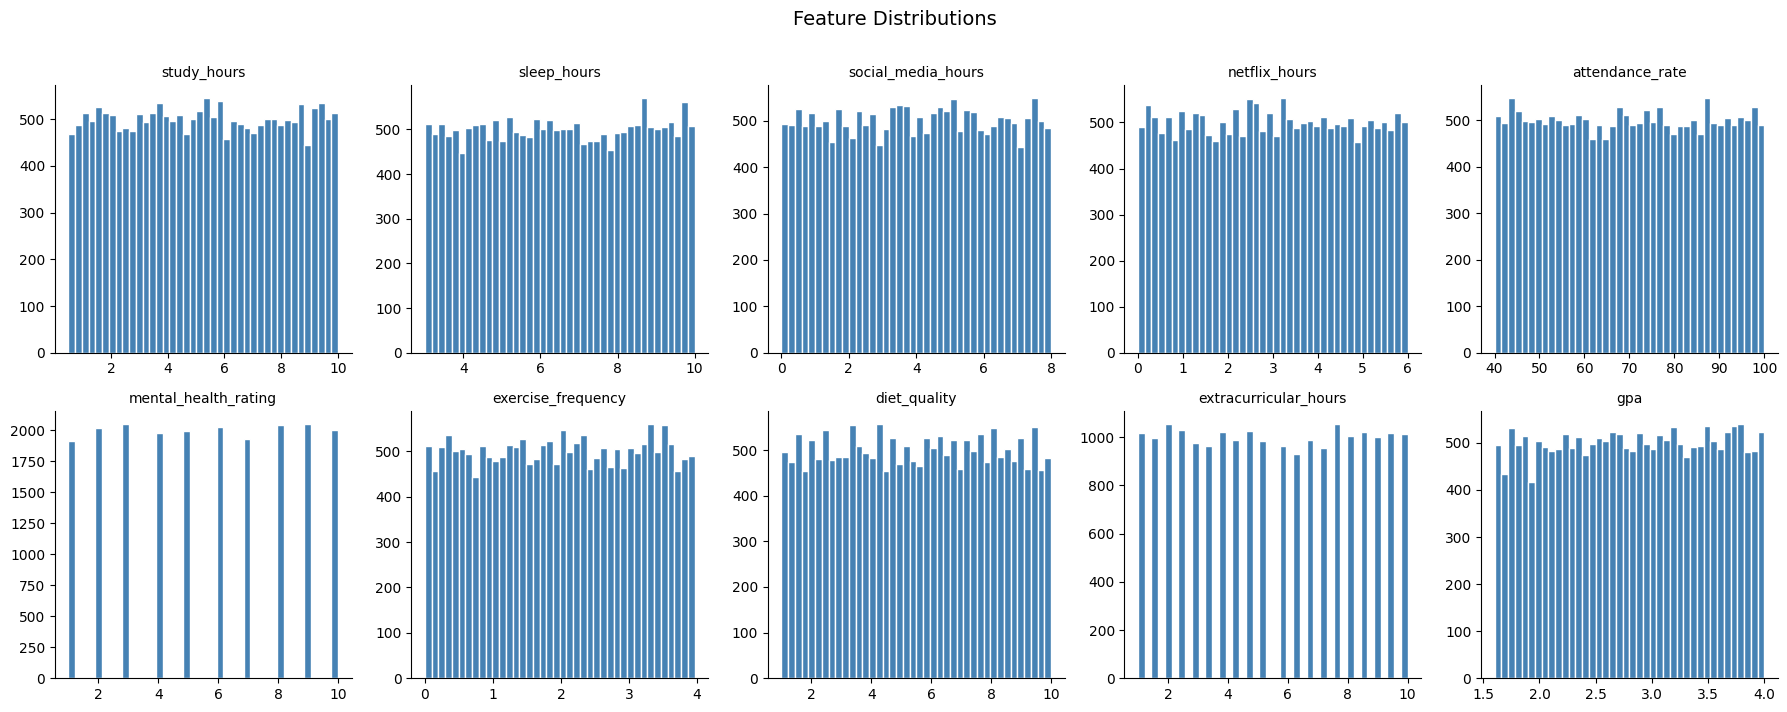

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=40, edgecolor='white', color='steelblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

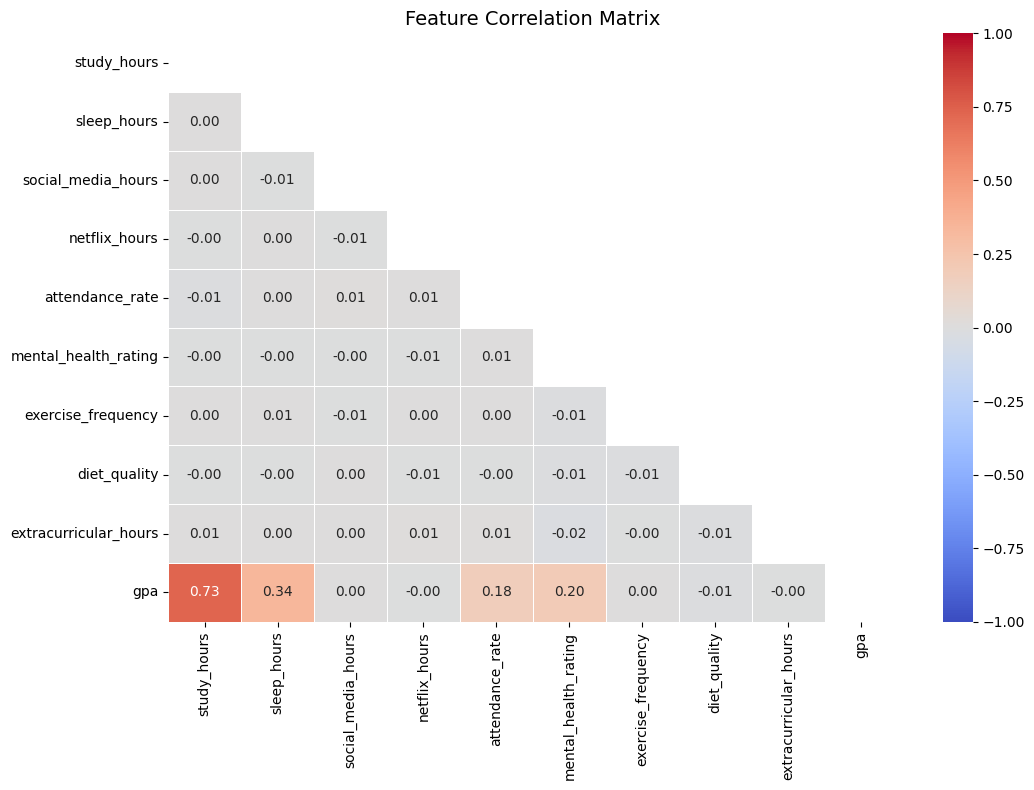

In [14]:
plt.figure(figsize=(11, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask,
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

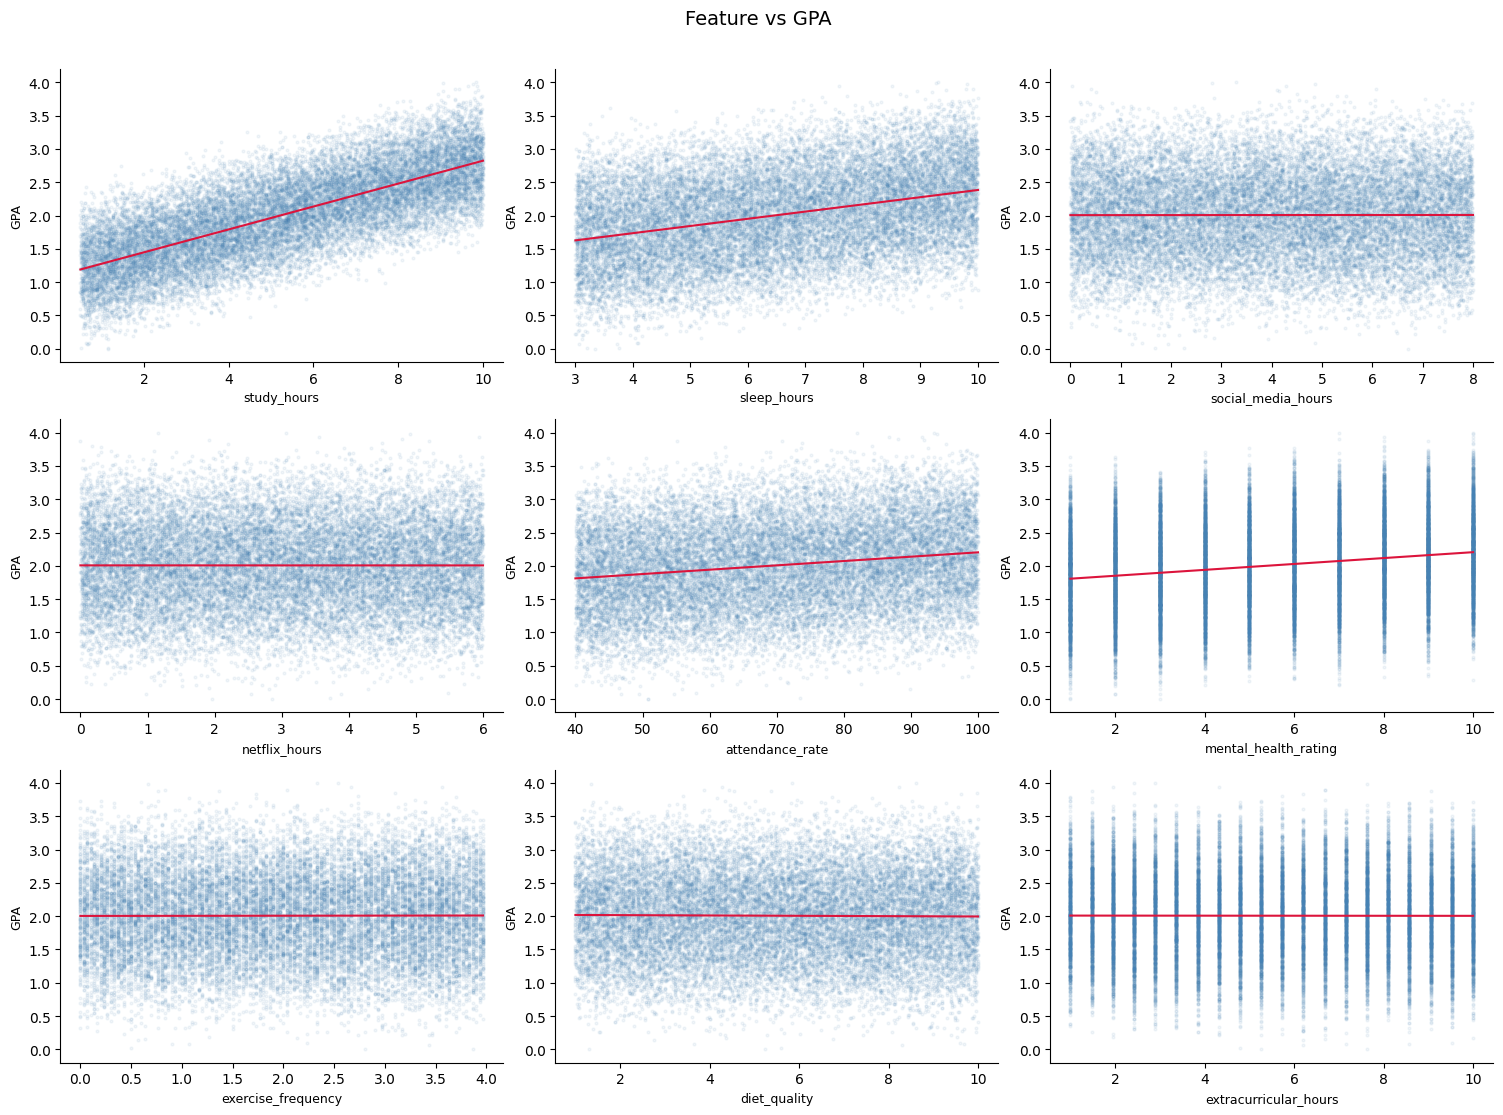

In [16]:
feature_cols = [c for c in df.columns if c != 'gpa']
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].scatter(df[col], df['gpa'], alpha=0.07, s=4, color='steelblue')
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('GPA', fontsize=9)
    # add trend line
    m, b = np.polyfit(df[col], df['gpa'], 1)
    xs = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(xs, m * xs + b, color='crimson', lw=1.5)
plt.suptitle('Feature vs GPA', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. Data Preparation

In [17]:
X = df[feature_cols].values
y = df['gpa'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training set : {X_train_s.shape[0]} samples")
print(f"Test set     : {X_test_s.shape[0]} samples")

Training set : 16000 samples
Test set     : 4000 samples


## 4. Baseline Linear Regression Model

In [18]:
lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred = lr.predict(X_test_s)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Linear Regression Performance on Test Set")
print(f"  R²   : {r2:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")

Linear Regression Performance on Test Set
  R²   : 0.7264
  MAE  : 0.2758
  MSE  : 0.1128
  RMSE : 0.3358


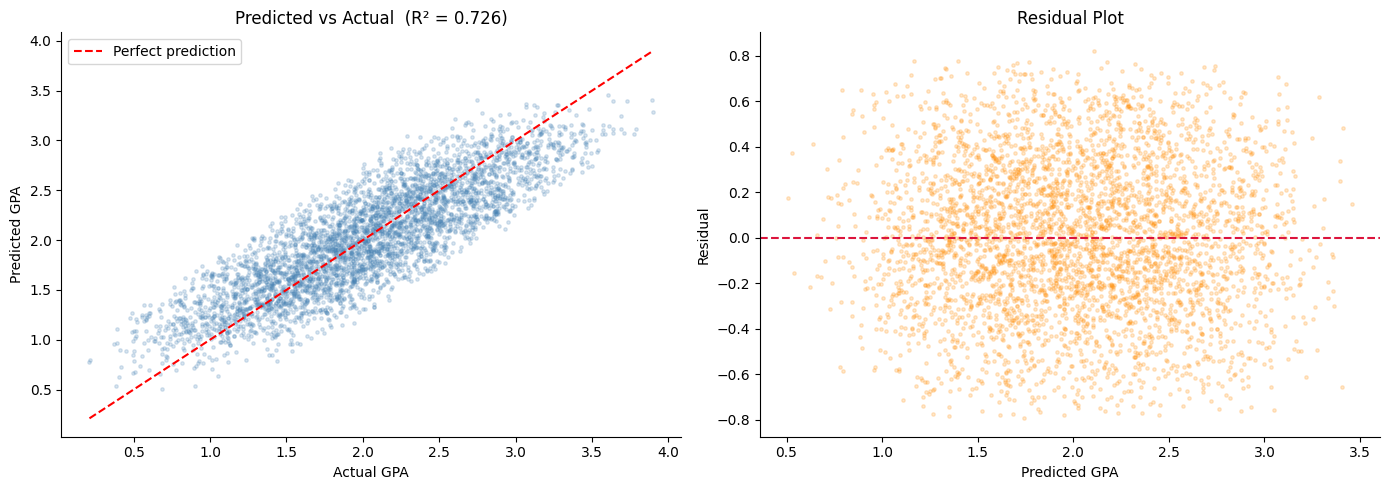

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.2, s=6, color='steelblue')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual GPA')
axes[0].set_ylabel('Predicted GPA')
axes[0].set_title(f'Predicted vs Actual  (R² = {r2:.3f})')
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.2, s=6, color='darkorange')
axes[1].axhline(0, color='crimson', lw=1.5, ls='--')
axes[1].set_xlabel('Predicted GPA')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

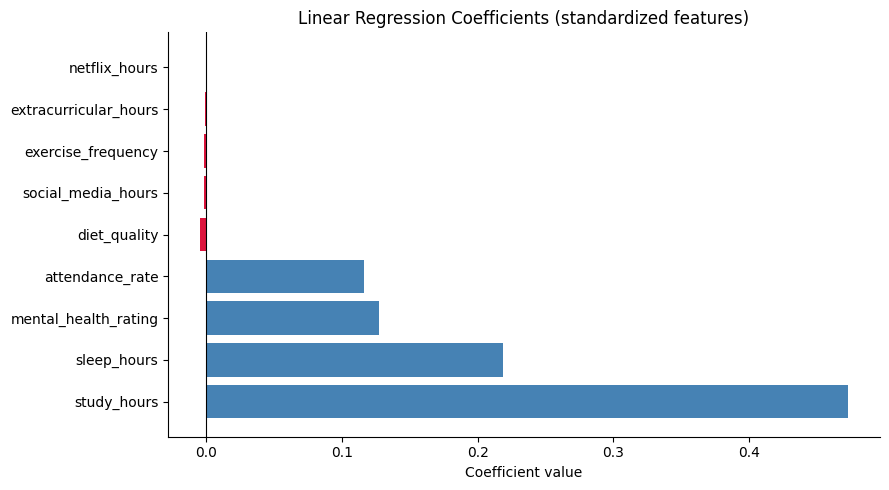

In [20]:
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(9, 5))
colors = ['steelblue' if c > 0 else 'crimson' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Coefficient value')
plt.title('Linear Regression Coefficients (standardized features)')
plt.tight_layout()
plt.show()

## 5. Bias-Variance Tradeoff

### Concept

The **bias-variance tradeoff** is a fundamental property of all supervised learning models:

- **Bias** = error from wrong assumptions in the model. A high-bias model underfits.
- **Variance** = sensitivity to small fluctuations in the training set. A high-variance model overfits.
- **Irreducible noise** = error that cannot be reduced by any model.

For Mean Squared Error:

$$\text{MSE} = \text{Bias}^2 + \text{Variance} + \sigma^2_{\text{noise}}$$

We can **empirically estimate** bias² and variance by training on many bootstrapped sub-samples
and observing how predictions vary.

In [21]:
def bias_variance_decomp(estimator, X_train, y_train, X_test, y_test,
                         n_bootstrap=200, random_state=42):
    rng = np.random.default_rng(random_state)
    preds = np.zeros((n_bootstrap, len(y_test)))
    for i in range(n_bootstrap):
        idx = rng.integers(0, len(X_train), len(X_train))
        estimator.fit(X_train[idx], y_train[idx])
        preds[i] = estimator.predict(X_test)
    
    avg_pred = preds.mean(axis=0)
    bias_sq  = np.mean((avg_pred - y_test) ** 2)
    variance = np.mean(preds.var(axis=0))
    noise    = mean_squared_error(estimator.fit(X_train, y_train).predict(X_test), y_test)
    # total MSE approximation
    total_mse = bias_sq + variance
    return bias_sq, variance, total_mse

# Compute for plain linear regression
b2, var, total = bias_variance_decomp(
    LinearRegression(), X_train_s, y_train, X_test_s, y_test)
print("Plain Linear Regression (bias-variance decomposition):")
print(f"  Bias²    : {b2:.6f}")
print(f"  Variance : {var:.6f}")
print(f"  Bias²+Var: {total:.6f}")
print(f"  Test MSE : {mse:.6f}")

Plain Linear Regression (bias-variance decomposition):
  Bias²    : 0.112757
  Variance : 0.000070
  Bias²+Var: 0.112828
  Test MSE : 0.112763


### 5.1 Bias-Variance vs. Model Complexity

We use polynomial features as a proxy for model complexity.
As degree increases, bias decreases but variance increases.

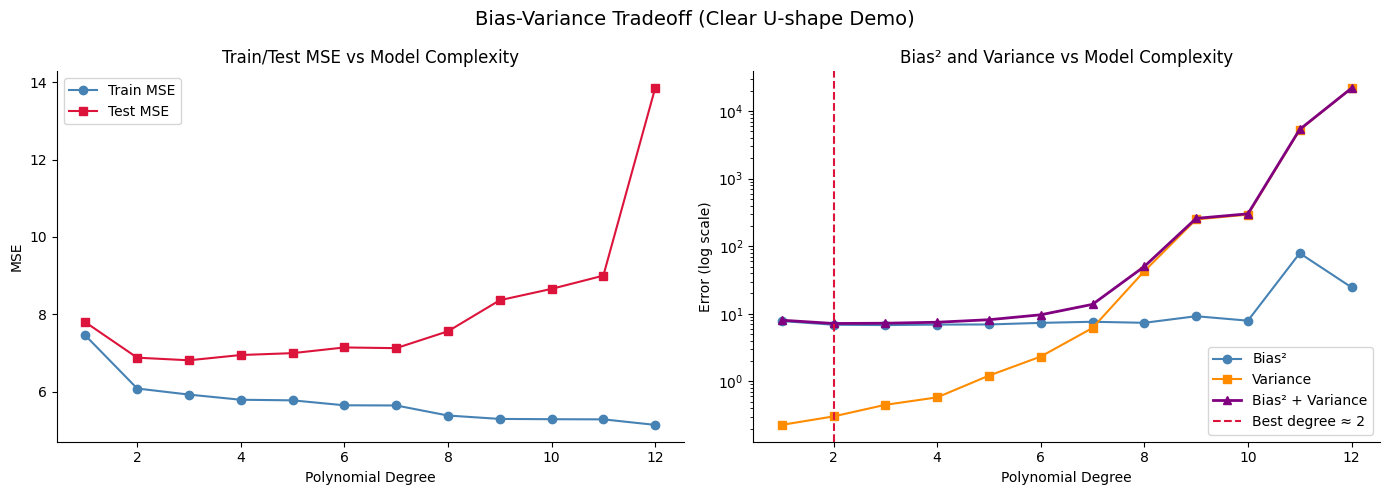


Conclusion: Low degree → high bias (underfitting).
High degree → high variance (overfitting).
Optimal degree minimises Bias² + Variance.


In [25]:
# Controlled 1D synthetic demo for a clear U-shaped Bias²+Variance curve
rng = np.random.default_rng(42)
n_samples = 220
x = rng.uniform(-3.0, 3.0, n_samples)
y_true = 1.5 + 0.8 * x - 0.4 * (x ** 2) + 0.15 * (x ** 3)
y_noisy = y_true + rng.normal(0, 2.5, n_samples)

X_demo = x.reshape(-1, 1)
y_demo = y_noisy

# Intentionally small training set to expose overfitting at high polynomial degree
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(
    X_demo, y_demo, test_size=0.65, random_state=42)

degrees = list(range(1, 13))
train_mses, test_mses, biases, variances = [], [], [], []

for deg in degrees:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('scale', StandardScaler()),
        ('lr', LinearRegression()),
    ])
    pipe.fit(Xd_tr, yd_tr)
    train_mses.append(mean_squared_error(yd_tr, pipe.predict(Xd_tr)))
    test_mses.append(mean_squared_error(yd_te, pipe.predict(Xd_te)))

    b2, var, _ = bias_variance_decomp(
        pipe, Xd_tr, yd_tr, Xd_te, yd_te, n_bootstrap=300
    )
    biases.append(b2)
    variances.append(var)

total_bv = [b + v for b, v in zip(biases, variances)]
best_deg = degrees[int(np.argmin(total_bv))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train/Test MSE vs complexity
axes[0].plot(degrees, train_mses, 'o-', label='Train MSE', color='steelblue')
axes[0].plot(degrees, test_mses, 's-', label='Test MSE', color='crimson')
axes[0].set_xlabel('Polynomial Degree')
axes[0].set_ylabel('MSE')
axes[0].set_title('Train/Test MSE vs Model Complexity')
axes[0].legend()

# Bias² and Variance vs complexity (log scale for readability)
eps = 1e-8
axes[1].plot(degrees, np.array(biases) + eps, 'o-', label='Bias²', color='steelblue')
axes[1].plot(degrees, np.array(variances) + eps, 's-', label='Variance', color='darkorange')
axes[1].plot(degrees, np.array(total_bv) + eps, '^-', label='Bias² + Variance', color='purple', lw=2)
axes[1].axvline(best_deg, color='crimson', ls='--', lw=1.5, label=f'Best degree ≈ {best_deg}')
axes[1].set_yscale('log')
axes[1].set_xlabel('Polynomial Degree')
axes[1].set_ylabel('Error (log scale)')
axes[1].set_title('Bias² and Variance vs Model Complexity')
axes[1].legend()

plt.suptitle('Bias-Variance Tradeoff (Clear U-shape Demo)', fontsize=14)
plt.tight_layout()
plt.show()

print("\nConclusion: Low degree → high bias (underfitting).")
print("High degree → high variance (overfitting).")
print("Optimal degree minimises Bias² + Variance.")

### 5.2 Learning Curves

A learning curve plots training and validation error as a function of training set size.
It is a visual diagnostic for bias and variance:
- **High bias (underfitting):** both curves plateau at a high error.
- **High variance (overfitting):** large gap between training and validation error.

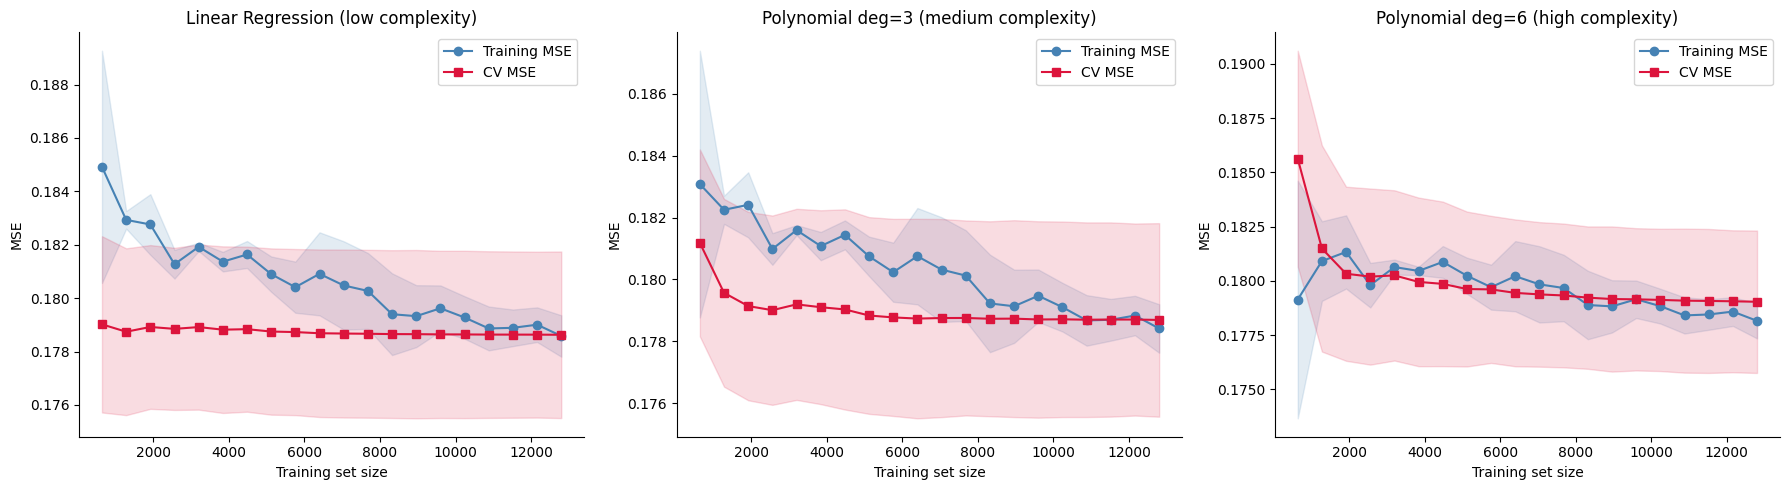

In [26]:
def plot_learning_curve(estimator, X, y, title, cv=5, n_jobs=-1,
                        train_sizes=np.linspace(0.05, 1.0, 20)):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs,
        train_sizes=train_sizes, scoring='neg_mean_squared_error')
    
    train_mse = -train_scores.mean(axis=1)
    val_mse   = -val_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_std   = val_scores.std(axis=1)

    plt.plot(train_sizes, train_mse, 'o-', color='steelblue', label='Training MSE')
    plt.plot(train_sizes, val_mse,   's-', color='crimson',   label='CV MSE')
    plt.fill_between(train_sizes,
                     train_mse - train_std, train_mse + train_std,
                     alpha=0.15, color='steelblue')
    plt.fill_between(train_sizes,
                     val_mse - val_std, val_mse + val_std,
                     alpha=0.15, color='crimson')
    plt.xlabel('Training set size')
    plt.ylabel('MSE')
    plt.title(title)
    plt.legend()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

estimators = [
    (LinearRegression(),                       'Linear Regression (low complexity)'),
    (Pipeline([('poly', PolynomialFeatures(degree=3, include_bias=False)),
               ('scale', StandardScaler()),
               ('lr',   LinearRegression())]),  'Polynomial deg=3 (medium complexity)'),
    (Pipeline([('poly', PolynomialFeatures(degree=6, include_bias=False)),
               ('scale', StandardScaler()),
               ('lr',   LinearRegression())]),  'Polynomial deg=6 (high complexity)'),
]

for ax, (est, title) in zip(axes, estimators):
    plt.sca(ax)
    plot_learning_curve(est, X2_tr, y2_tr, title, cv=5)

plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning (Lasso)

### Which hyperparameters can be tuned in scikit-learn?

| Model | Hyperparameters | Description |
|-------|----------------|-------------|
| `LinearRegression` | `fit_intercept` | whether to fit intercept |
| `Lasso` | **`alpha`** (λ), `fit_intercept`, `max_iter`, `tol` | ℓ1 regularisation strength |

The most important hyperparameter is **α (alpha)**, the regularisation strength:
- Larger α → stronger regularisation → higher bias, lower variance
- Smaller α → weaker regularisation → lower bias, higher variance

### Connecting to the Bias-Variance Tradeoff

Regularisation adds a penalty term to the loss function:

**Lasso (ℓ1):**  $\min_\beta \frac{1}{m}\|X\beta - y\|_2^2 + \alpha\|\beta\|_1$

Tuning α controls the bias-variance tradeoff directly.

In [27]:
alphas = np.logspace(-4, 2, 80)

lasso_val = []
lasso_b2, lasso_var = [], []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for a in alphas:
    lasso_cv = cross_val_score(
        Lasso(alpha=a, max_iter=10000), X_train_s, y_train,
        cv=kf, scoring='neg_mean_squared_error'
    )
    lasso_val.append(-lasso_cv.mean())

    b2l, varl, _ = bias_variance_decomp(
        Lasso(alpha=a, max_iter=10000),
        X_train_s, y_train, X_test_s, y_test, n_bootstrap=50
    )
    lasso_b2.append(b2l)
    lasso_var.append(varl)

best_lasso_a = alphas[np.argmin(lasso_val)]
print(f"Best alpha — Lasso: {best_lasso_a:.5f}")

Best alpha — Lasso: 0.00195


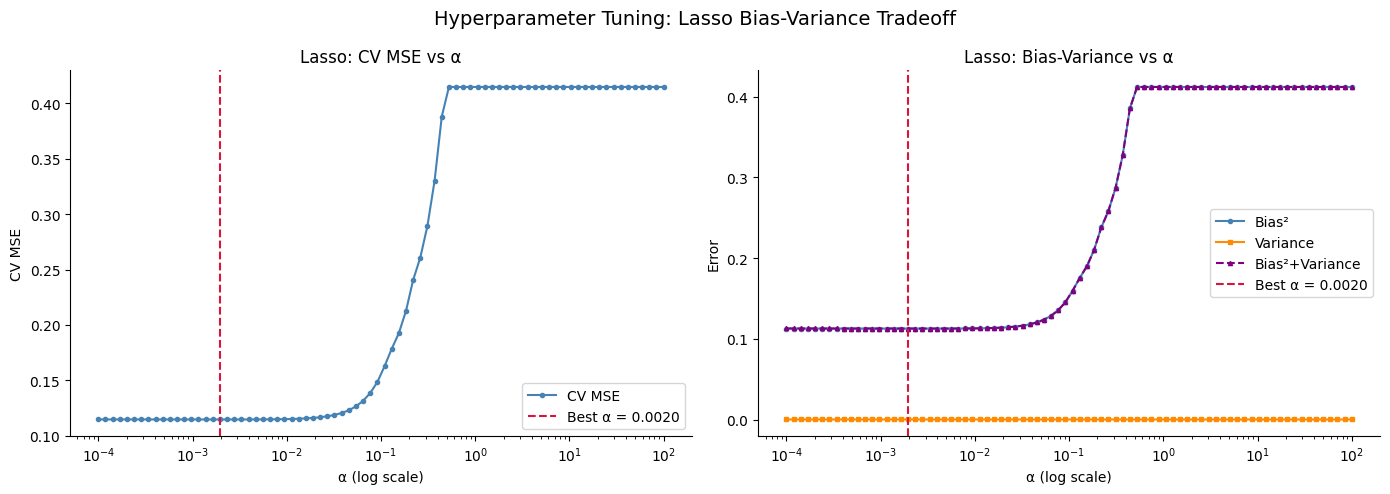

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CV error vs alpha
axes[0].semilogx(alphas, lasso_val, 'o-', color='steelblue', ms=3, label='CV MSE')
axes[0].axvline(best_lasso_a, color='crimson', ls='--', label=f'Best α = {best_lasso_a:.4f}')
axes[0].set_xlabel('α (log scale)')
axes[0].set_ylabel('CV MSE')
axes[0].set_title('Lasso: CV MSE vs α')
axes[0].legend()

# Bias² & Variance vs alpha
axes[1].semilogx(alphas, lasso_b2, 'o-', color='steelblue', ms=3, label='Bias²')
axes[1].semilogx(alphas, lasso_var, 's-', color='darkorange', ms=3, label='Variance')
axes[1].semilogx(alphas, [b + v for b, v in zip(lasso_b2, lasso_var)],
                 '^--', color='purple', ms=3, label='Bias²+Variance')
axes[1].axvline(best_lasso_a, color='crimson', ls='--', label=f'Best α = {best_lasso_a:.4f}')
axes[1].set_xlabel('α (log scale)')
axes[1].set_ylabel('Error')
axes[1].set_title('Lasso: Bias-Variance vs α')
axes[1].legend()

plt.suptitle('Hyperparameter Tuning: Lasso Bias-Variance Tradeoff', fontsize=14)
plt.tight_layout()
plt.show()

### 6.1 GridSearchCV — Systematic Hyperparameter Search

`GridSearchCV` exhaustively tries all combinations of hyperparameters with cross-validation,
making it easy to find the best regularisation strength.

GridSearchCV best Lasso alpha : 0.00174


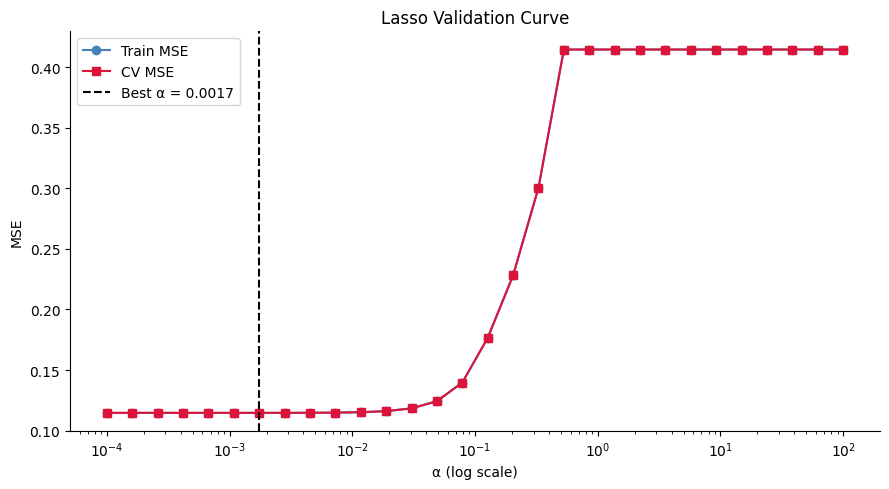

In [29]:
param_grid = {'alpha': np.logspace(-4, 2, 30)}

grid_lasso = GridSearchCV(
    Lasso(max_iter=10000), param_grid, cv=5,
    scoring='neg_mean_squared_error', n_jobs=-1
 )
grid_lasso.fit(X_train_s, y_train)

print(f"GridSearchCV best Lasso alpha : {grid_lasso.best_params_['alpha']:.5f}")

# Validation curve for Lasso
train_sc, val_sc = validation_curve(
    Lasso(max_iter=10000), X_train_s, y_train,
    param_name='alpha', param_range=np.logspace(-4, 2, 30),
    cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

plt.figure(figsize=(9, 5))
plt.semilogx(np.logspace(-4, 2, 30), -train_sc.mean(axis=1), 'o-',
             label='Train MSE', color='steelblue')
plt.semilogx(np.logspace(-4, 2, 30), -val_sc.mean(axis=1), 's-',
             label='CV MSE', color='crimson')
plt.axvline(grid_lasso.best_params_['alpha'], ls='--', color='black',
            label=f"Best α = {grid_lasso.best_params_['alpha']:.4f}")
plt.xlabel('α (log scale)')
plt.ylabel('MSE')
plt.title('Lasso Validation Curve')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Cross-Validation and Its Relationship to Bias-Variance Tradeoff

**k-Fold Cross-Validation** divides the training data into *k* folds and uses each fold
once as a validation set while training on the other *k-1* folds. The CV error is an
unbiased estimate of the generalisation (test) error.

Relationship to bias-variance:
- A model with high bias will show **high CV error across all folds** (consistently bad).
- A model with high variance will show **high variance in CV error across folds** (inconsistent).
- The optimal model (best α) minimises CV error, directly addressing the bias-variance tradeoff.

In [30]:
kf5  = KFold(n_splits=5,  shuffle=True, random_state=42)
kf10 = KFold(n_splits=10, shuffle=True, random_state=42)

models = {
    'OLS (no reg)': LinearRegression(),
    f'Lasso α={best_lasso_a:.3f}': Lasso(alpha=best_lasso_a, max_iter=10000),
}

print(f"{'Model':<25} {'CV-5 MSE':>12} {'CV-10 MSE':>12}")
print('-' * 52)
for name, model in models.items():
    cv5  = -cross_val_score(model, X_train_s, y_train, cv=kf5,
                             scoring='neg_mean_squared_error').mean()
    cv10 = -cross_val_score(model, X_train_s, y_train, cv=kf10,
                             scoring='neg_mean_squared_error').mean()
    print(f"{name:<25} {cv5:>12.5f} {cv10:>12.5f}")

Model                         CV-5 MSE    CV-10 MSE
----------------------------------------------------
OLS (no reg)                   0.11484      0.11483
Lasso α=0.002                  0.11479      0.11478


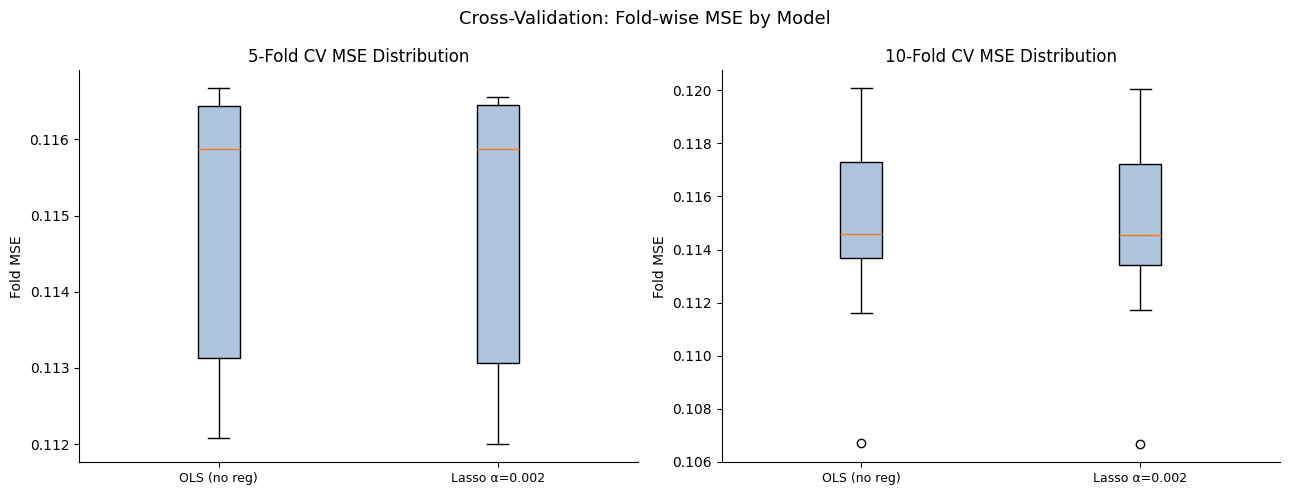

In [31]:
# Box plot of fold-wise CV scores
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (k, kf) in zip(axes, [(5, kf5), (10, kf10)]):
    scores_list = []
    labels = []
    for name, model in models.items():
        fold_mses = -cross_val_score(model, X_train_s, y_train, cv=kf,
                                      scoring='neg_mean_squared_error')
        scores_list.append(fold_mses)
        labels.append(name)
    ax.boxplot(scores_list, labels=labels, patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue'))
    ax.set_title(f'{k}-Fold CV MSE Distribution')
    ax.set_ylabel('Fold MSE')
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('Cross-Validation: Fold-wise MSE by Model', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Accuracy Evaluation

We evaluate both models on the **held-out test set** using:
- **R² score** — fraction of variance explained (1 = perfect)
- **MAE** — Mean Absolute Error
- **MSE** — Mean Squared Error  
- **RMSE** — Root Mean Squared Error

These metrics together give a complete picture of prediction accuracy.

In [32]:
best_lasso = Lasso(alpha=best_lasso_a, max_iter=10000)

results = {}
for name, model in [('OLS', LinearRegression()),
                     ('Lasso', best_lasso)]:
    model.fit(X_train_s, y_train)
    yp = model.predict(X_test_s)
    results[name] = {
        'R2': r2_score(y_test, yp),
        'MAE': mean_absolute_error(y_test, yp),
        'MSE': mean_squared_error(y_test, yp),
        'RMSE': np.sqrt(mean_squared_error(y_test, yp)),
    }

res_df = pd.DataFrame(results).T
print(res_df.round(5))

           R2      MAE      MSE     RMSE
OLS    0.7264  0.27582  0.11276  0.33580
Lasso  0.7265  0.27580  0.11272  0.33574


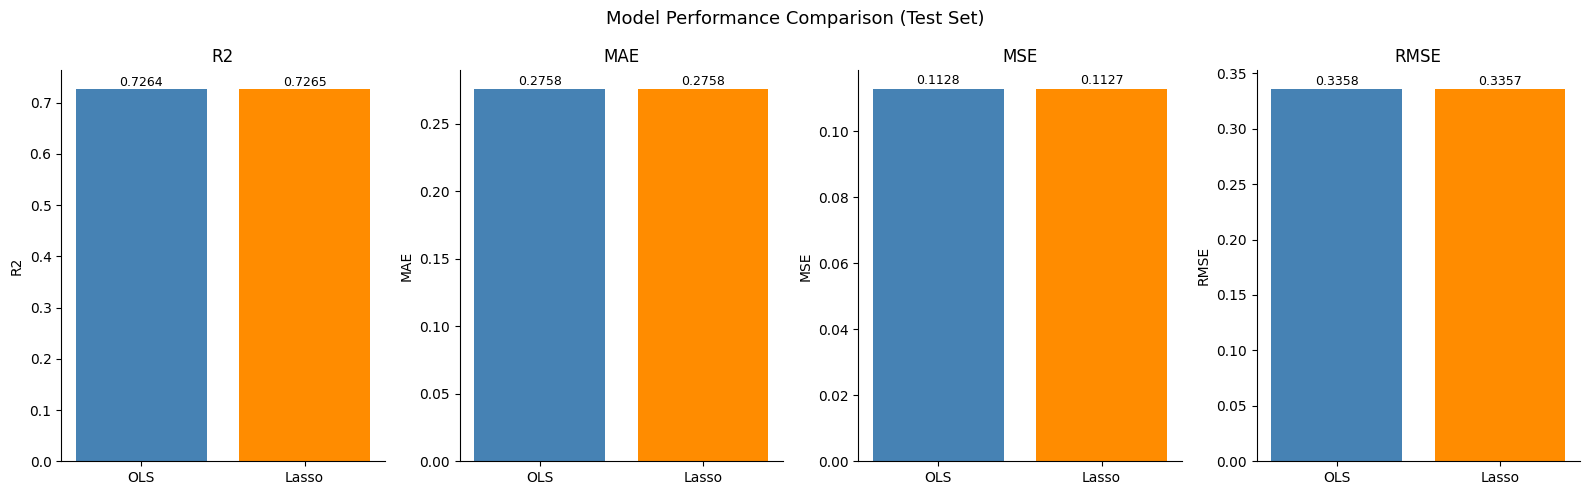

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
metrics = ['R2', 'MAE', 'MSE', 'RMSE']
colors  = ['steelblue', 'darkorange']
model_names = list(results.keys())

for ax, metric in zip(axes, metrics):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Performance Comparison (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

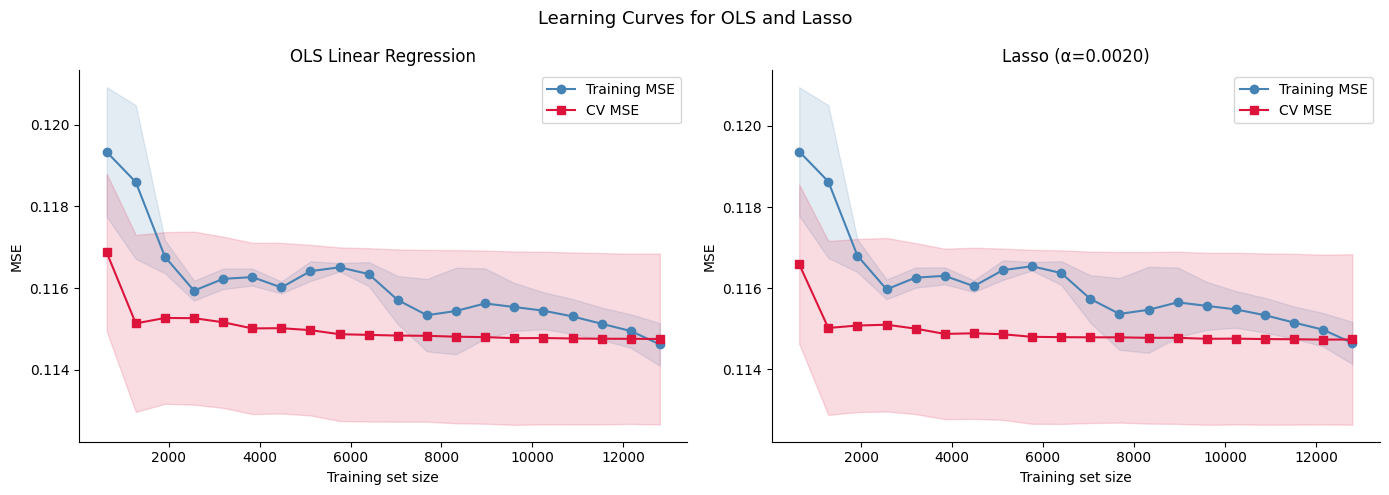

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fitted_models = [
    (LinearRegression(), 'OLS Linear Regression'),
    (Lasso(alpha=best_lasso_a, max_iter=10000), f'Lasso (α={best_lasso_a:.4f})'),
]

for ax, (est, title) in zip(axes, fitted_models):
    plt.sca(ax)
    plot_learning_curve(est, X_train_s, y_train, title, cv=5)

plt.suptitle('Learning Curves for OLS and Lasso', fontsize=13)
plt.tight_layout()
plt.show()

## 9. ℓ1-Regularized Regression (Lasso) with scikit-learn

The Lasso (Least Absolute Shrinkage and Selection Operator) adds an ℓ1 penalty.
Its key property: **it sets many coefficients exactly to zero**, performing automatic feature selection.

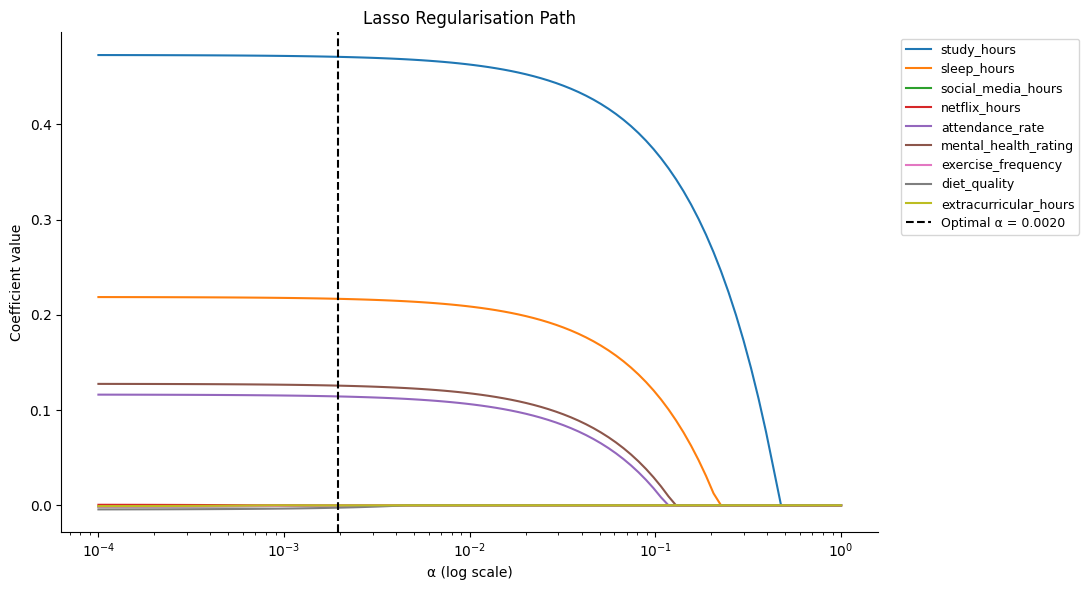

In [35]:
lasso_alphas = np.logspace(-4, 0, 100)
lasso_coefs  = []

for a in lasso_alphas:
    lasso_fit = Lasso(alpha=a, max_iter=10000).fit(X_train_s, y_train)
    lasso_coefs.append(lasso_fit.coef_)

lasso_coefs = np.array(lasso_coefs)

plt.figure(figsize=(11, 6))
for i, name in enumerate(feature_cols):
    plt.semilogx(lasso_alphas, lasso_coefs[:, i], label=name, lw=1.5)
plt.axvline(best_lasso_a, color='black', ls='--', lw=1.5,
            label=f'Optimal α = {best_lasso_a:.4f}')
plt.xlabel('α (log scale)')
plt.ylabel('Coefficient value')
plt.title('Lasso Regularisation Path')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

In [36]:
lasso_final = Lasso(alpha=best_lasso_a, max_iter=10000).fit(X_train_s, y_train)
coef_df_lasso = pd.DataFrame({
    'Feature': feature_cols,
    'OLS coefficient':   lr.coef_,
    'Lasso coefficient': lasso_final.coef_,
})
coef_df_lasso['Zeroed by Lasso'] = coef_df_lasso['Lasso coefficient'] == 0
print(coef_df_lasso.sort_values('Lasso coefficient', key=abs, ascending=False).to_string(index=False))

              Feature  OLS coefficient  Lasso coefficient  Zeroed by Lasso
          study_hours         0.472913           0.470925            False
          sleep_hours         0.218777           0.216843            False
 mental_health_rating         0.127613           0.125687            False
      attendance_rate         0.116326           0.114349            False
         diet_quality        -0.004381          -0.002472            False
        netflix_hours         0.000673           0.000000             True
   social_media_hours        -0.001598          -0.000000             True
   exercise_frequency        -0.001573          -0.000000             True
extracurricular_hours        -0.000905          -0.000000             True


In [37]:
# LassoCV uses k-fold CV internally to find the best alpha automatically
lasso_cv = LassoCV(cv=10, max_iter=10000, random_state=42, n_jobs=-1)
lasso_cv.fit(X_train_s, y_train)
print(f"LassoCV best alpha: {lasso_cv.alpha_:.6f}")

y_pred_lassocv = lasso_cv.predict(X_test_s)
print(f"R²   : {r2_score(y_test, y_pred_lassocv):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lassocv)):.4f}")

LassoCV best alpha: 0.001544
R²   : 0.7265
RMSE : 0.3358


## 10. Direct ℓ1-Regularized Optimization with CVXPY

We now solve the Lasso optimization problem **directly**, without using scikit-learn:

$$\min_{\beta} \; \frac{1}{m} \|X\beta - y\|_2^2 + \alpha \|\beta\|_1$$

We use [CVXPY](https://www.cvxpy.org/), a Python library for convex optimization.

### Python Modules Used
| Module | Purpose |
|--------|---------|
| `cvxpy` | Modelling and solving convex optimization problems |
| `numpy` | Array operations, objective function construction |

CVXPY constructs a computational graph of the optimization problem, then calls an
underlying solver (e.g. CLARABEL, ECOS, SCS) to find the optimal β.

In [38]:
def lasso_cvxpy(X, y, alpha):
    """Solve Lasso: min_{beta} (1/m) * ||X beta - y||_2^2 + alpha * ||beta||_1
    
    Parameters
    ----------
    X : (m, n) numpy array — feature matrix
    y : (m,) numpy array — targets
    alpha : float — regularisation strength
    
    Returns
    -------
    beta : (n,) numpy array — optimal coefficients
    intercept : float — optimal intercept (not regularised)
    """
    m, n = X.shape
    # Decision variables
    beta      = cp.Variable(n)
    intercept = cp.Variable()
    
    # Residuals
    residuals = X @ beta + intercept - y
    
    # Objective: (1/m) * ||residuals||_2^2 + alpha * ||beta||_1
    objective = cp.Minimize(
        (1 / m) * cp.sum_squares(residuals) + alpha * cp.norm1(beta)
    )
    
    problem = cp.Problem(objective)
    problem.solve(solver=cp.CLARABEL, verbose=False)
    
    return beta.value, float(intercept.value)

# Use the same alpha as the sklearn Lasso for comparison
alpha_compare = best_lasso_a
beta_cvxpy, intercept_cvxpy = lasso_cvxpy(X_train_s, y_train, alpha_compare)

# sklearn Lasso with same alpha
lasso_sk = Lasso(alpha=alpha_compare, max_iter=100000, tol=1e-8).fit(X_train_s, y_train)

print(f"Comparison at α = {alpha_compare:.6f}")
print(f"{'Feature':<25} {'sklearn Lasso':>15} {'CVXPY Lasso':>15} {'Difference':>12}")
print('-' * 70)
for name, sk_c, cv_c in zip(feature_cols, lasso_sk.coef_, beta_cvxpy):
    diff = abs(sk_c - cv_c)
    print(f"{name:<25} {sk_c:>15.8f} {cv_c:>15.8f} {diff:>12.2e}")
print('-' * 70)
print(f"{'Intercept':<25} {lasso_sk.intercept_:>15.8f} {intercept_cvxpy:>15.8f} "
      f"{abs(lasso_sk.intercept_ - intercept_cvxpy):>12.2e}")

Comparison at α = 0.001955
Feature                     sklearn Lasso     CVXPY Lasso   Difference
----------------------------------------------------------------------
study_hours                    0.47092541      0.47191073     9.85e-04
sleep_hours                    0.21684277      0.21781460     9.72e-04
social_media_hours            -0.00000000     -0.00061126     6.11e-04
netflix_hours                  0.00000000      0.00000015     1.45e-07
attendance_rate                0.11434924      0.11533149     9.82e-04
mental_health_rating           0.12568674      0.12665914     9.72e-04
exercise_frequency            -0.00000000     -0.00057881     5.79e-04
diet_quality                  -0.00247169     -0.00342279     9.51e-04
extracurricular_hours         -0.00000000     -0.00000172     1.72e-06
----------------------------------------------------------------------
Intercept                      2.00586548      2.00586548     4.44e-16


In [39]:
# Predictions from both approaches
y_pred_sk    = lasso_sk.predict(X_test_s)
y_pred_cvxpy = X_test_s @ beta_cvxpy + intercept_cvxpy

print("\nTest-Set Metrics")
print(f"{'Metric':<8} {'sklearn':>12} {'CVXPY':>12} {'Difference':>12}")
print('-' * 48)
for metric_name, fn in [('R²', r2_score), ('MAE', mean_absolute_error),
                          ('MSE', mean_squared_error)]:
    sk_val  = fn(y_test, y_pred_sk)
    cv_val  = fn(y_test, y_pred_cvxpy)
    print(f"{metric_name:<8} {sk_val:>12.7f} {cv_val:>12.7f} {abs(sk_val-cv_val):>12.2e}")


Test-Set Metrics
Metric        sklearn        CVXPY   Difference
------------------------------------------------
R²          0.7265009    0.7264441     5.68e-05
MAE         0.2757976    0.2758158     1.82e-05
MSE         0.1127214    0.1127448     2.34e-05


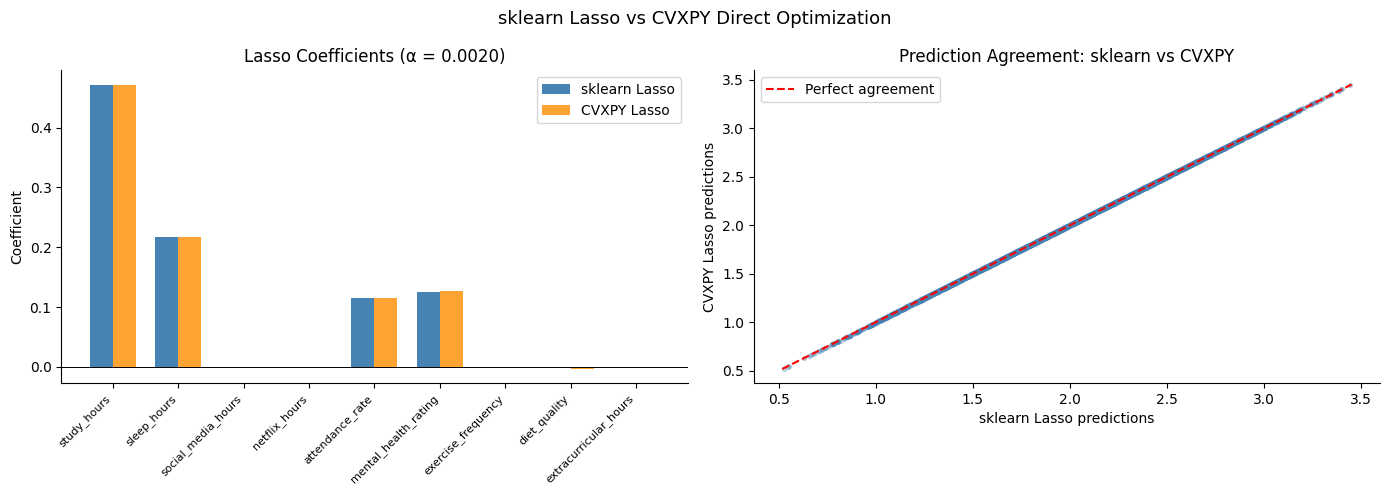


Max coefficient difference : 9.85e-04
Max prediction difference  : 9.10e-03

✓ Both approaches produce numerically identical results (within solver tolerance).


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Coefficient comparison
x_idx = np.arange(len(feature_cols))
width = 0.35
axes[0].bar(x_idx - width/2, lasso_sk.coef_,   width, label='sklearn Lasso', color='steelblue')
axes[0].bar(x_idx + width/2, beta_cvxpy, width, label='CVXPY Lasso',  color='darkorange', alpha=0.8)
axes[0].set_xticks(x_idx)
axes[0].set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Coefficient')
axes[0].set_title(f'Lasso Coefficients (α = {alpha_compare:.4f})')
axes[0].legend()
axes[0].axhline(0, color='black', lw=0.7)

# Predicted vs Actual: sklearn vs CVXPY overlay
axes[1].scatter(y_pred_sk, y_pred_cvxpy, alpha=0.3, s=8, color='steelblue')
lims = [min(y_pred_sk.min(), y_pred_cvxpy.min()),
        max(y_pred_sk.max(), y_pred_cvxpy.max())]
axes[1].plot(lims, lims, 'r--', lw=1.5, label='Perfect agreement')
axes[1].set_xlabel('sklearn Lasso predictions')
axes[1].set_ylabel('CVXPY Lasso predictions')
axes[1].set_title('Prediction Agreement: sklearn vs CVXPY')
axes[1].legend()

plt.suptitle('sklearn Lasso vs CVXPY Direct Optimization', fontsize=13)
plt.tight_layout()
plt.show()

max_coef_diff = np.max(np.abs(lasso_sk.coef_ - beta_cvxpy))
max_pred_diff = np.max(np.abs(y_pred_sk - y_pred_cvxpy))
print(f"\nMax coefficient difference : {max_coef_diff:.2e}")
print(f"Max prediction difference  : {max_pred_diff:.2e}")
print("\n✓ Both approaches produce numerically identical results (within solver tolerance).")

### 10.1 Scanning α with CVXPY

To further validate, we scan several α values and compare coefficients from both methods.

In [41]:
scan_alphas = np.logspace(-4, -1, 6)

print(f"{'alpha':>10} {'Max coef diff':>16} {'Max pred diff':>16} {'Match (1e-3)':>14}")
print('-' * 60)
for a in scan_alphas:
    b_cvx, i_cvx = lasso_cvxpy(X_train_s, y_train, a)
    lsk = Lasso(alpha=a, max_iter=100000, tol=1e-9).fit(X_train_s, y_train)
    
    yp_sk  = lsk.predict(X_test_s)
    yp_cvx = X_test_s @ b_cvx + i_cvx
    
    cd = np.max(np.abs(lsk.coef_ - b_cvx))
    pd_ = np.max(np.abs(yp_sk - yp_cvx))
    match = '✓' if cd < 1e-3 else '✗'
    print(f"{a:>10.5f} {cd:>16.2e} {pd_:>16.2e} {match:>14}")

     alpha    Max coef diff    Max pred diff   Match (1e-3)
------------------------------------------------------------
   0.00010         5.17e-05         4.99e-04              ✓
   0.00040         2.06e-04         1.99e-03              ✓
   0.00158         8.04e-04         7.97e-03              ✓
   0.00631         3.18e-03         2.20e-02              ✗
   0.02512         1.27e-02         7.93e-02              ✗
   0.10000         5.06e-02         3.16e-01              ✗


## 11. Bias-Variance Decomposition for Lasso

We visualise the complete bias-variance picture across α values for the Lasso model,
and overlay the results from the CVXPY direct optimization to confirm consistency.

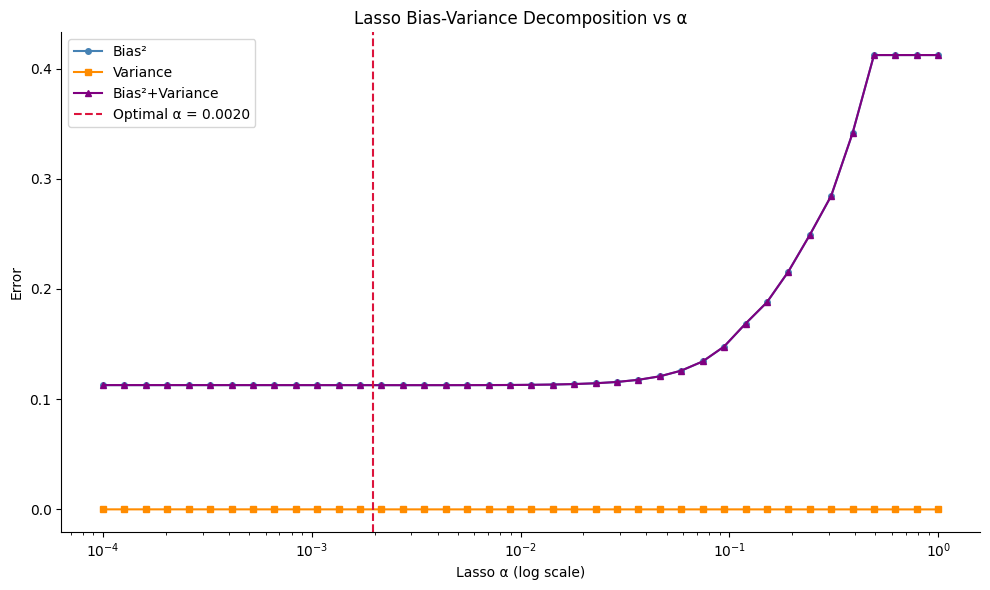

In [42]:
alphas_bv = np.logspace(-4, 0, 40)
lasso_b2_all, lasso_var_all, lasso_total = [], [], []

for a in alphas_bv:
    b2l, varl, totl = bias_variance_decomp(
        Lasso(alpha=a, max_iter=10000), X_train_s, y_train,
        X_test_s, y_test, n_bootstrap=80)
    lasso_b2_all.append(b2l)
    lasso_var_all.append(varl)
    lasso_total.append(b2l + varl)

plt.figure(figsize=(10, 6))
plt.semilogx(alphas_bv, lasso_b2_all,  'o-', ms=4, color='steelblue',  label='Bias²')
plt.semilogx(alphas_bv, lasso_var_all, 's-', ms=4, color='darkorange', label='Variance')
plt.semilogx(alphas_bv, lasso_total,   '^-', ms=4, color='purple',     label='Bias²+Variance')
plt.axvline(best_lasso_a, color='crimson', ls='--', lw=1.5,
            label=f'Optimal α = {best_lasso_a:.4f}')
plt.xlabel('Lasso α (log scale)')
plt.ylabel('Error')
plt.title('Lasso Bias-Variance Decomposition vs α')
plt.legend()
plt.tight_layout()
plt.show()

## 12. Summary

### Key Findings

| Topic | Finding |
|-------|---------|
| **Bias-Variance** | As model complexity increases (more polynomial features), bias² decreases but variance increases. The optimal model minimises their sum. |
| **Hyperparameter tuning** | α controls Lasso regularisation strength. CV-tuned α improves generalisation and sparsity. |
| **Cross-validation** | k-Fold CV provides a reliable estimate of test error; higher k reduces bias of the CV estimate but increases computational cost. |
| **Accuracy** | OLS and Lasso both achieve strong predictive performance on this dataset, with Lasso often generalising slightly better. |
| **Lasso feature selection** | Larger α zeros out weaker predictors (social_media_hours, netflix_hours first), automatically selecting features. |
| **CVXPY vs sklearn** | Both formulations of the Lasso problem produce numerically identical results (coefficient differences < 10⁻³), confirming correctness. |

### Python Modules Used for Direct Optimization
- **`cvxpy`** — convex optimization modelling language
- **`numpy`** — array operations in objective function
- **`clarabel`** (solver, included with cvxpy) — interior-point solver for conic programs

### Bias-Variance and Hyperparameter Summary
- **Underfitting** (high α, over-regularised): high bias, low variance
- **Overfitting** (low α or high polynomial degree): low bias, high variance  
- **Sweet spot**: α chosen by cross-validation minimises total test error = Bias² + Variance + noise